In [1]:
import numpy as np
import pydmd
from pydmd import DMD
from epinetwork.Simulation import simulation
from epinetwork.Models import VectorBorne_Endemic
from epinetwork.MobilityNetwork import MobilityNetwork
from epinetwork.Control_protocol import controlProtocol
from epinetwork.SimulationsEnsemble import simulationsEnsemble
from epinetwork.Control_protocol import RandomControl, IndexBasedControl, noControl
#Para graficos 
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.patches as patches
import math
from pydmd.plotter import plot_eigs
#Para presentación de resultados 
from numpy.linalg import matrix_rank
import pandas as pd
from scipy import stats
# configuración de warnings
import warnings
warnings.filterwarnings('ignore')

# Funciones 

In [4]:
def gen_labels(reg):
    lab = []
    for i in range(1, reg + 1):
        lab.append("S_h" + str(i))
        lab.append("I_h" + str(i))
        lab.append("R_h" + str(i))
        lab.append("S_v" + str(i))
        lab.append("I_v" + str(i))

    return lab


def dominant_modes(dmd, T=1, top=None):
    """
    Ordena modos DMD por dominancia modal.

    Parámetros
    dmd : objeto PyDMD 
    T : horizonte temporal
    top : ranking de modos a regresar

    Returns
    df : DataFrame 
    modes_sorted : matriz con modos ordenados
    """

    eigs = dmd.eigs
    amps = dmd.amplitudes
    modes = dmd.modes

    score = np.abs(amps) * np.abs(eigs)**T

    df = pd.DataFrame({
        "mode": np.arange(1, len(eigs)+1),
        "eigenvalue": eigs,
        "|lambda|": np.abs(eigs),
        "amplitude": amps,
        "|b|": np.abs(amps),
        "score": score
    })

    df = df.sort_values("score", ascending=False).reset_index(drop=True)

    if top is not None:
        df = df.iloc[:top]

    idx = df["mode"].values - 1
    modes_sorted = modes[:, idx]

    return df, modes_sorted



# Funciones Gráficos 

In [7]:
def RegValGrid(reg, var, sol, tiempo, lab):
    import matplotlib.gridspec as gridspec
    
    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 3, figure=fig)  
    
    axes_flat = []
    for i in range(2):
        for j in range(3):
            if i*3 + j < var:
                ax = fig.add_subplot(gs[i, j])
                axes_flat.append(ax)
    
    for idx, ax in enumerate(axes_flat):
        for region_idx in range(reg):
            ax.plot(tiempo, sol[region_idx, idx, :], 
                   label=f'{region_idx+1}', linewidth=1)
        ax.set_title(lab[idx], fontsize=8)
        ax.set_xlabel('Tiempo', fontsize=7)
        ax.set_ylabel('Población', fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.2)
        ax.legend(loc='best', fontsize=5, ncol=2)
    
    fig.suptitle('Modelo Metapoblacional', fontsize=10)
    plt.tight_layout()
    plt.savefig("grafico_metapoblacional.jpg", bbox_inches="tight")
    plt.show()

def RegVal(reg, var, sol, tiempo, lab):
    for region_idx in range(reg):
        plt.figure(figsize=(10, 6))
        for var_idx in range(var):
            plt.plot(tiempo, sol[region_idx, var_idx, :], 
                     label=lab[var_idx])
        
    plt.xlabel('Tiempo')
    plt.ylabel('Poblacion')
    plt.title(f'Región {region_idx+1} - Todas las variables')
    plt.legend()
    plt.grid(True)
    plt.show()

def animacion(variable,regiones, sol, tiempo, var_label, save='animacion'):
    fig, ax = plt.subplots(figsize=(10, 6))
    def animar(frame):
        ax.clear()
        for region_idx in range(regiones):
            ax.plot(tiempo[:frame+1], sol[region_idx, variable, :frame+1], 
                    label=f'Reg {region_idx+1}')
        ax.set_xlim(0, tiempo[-1])
        ax.set_ylim(np.min(sol[:, variable, :]), np.max(sol[:, variable, :]))
        ax.set_xlabel('Tiempo')
        ax.set_ylabel(var_label)
        ax.set_title(f'Animación - t = {tiempo[frame]:.2f}')
        ax.legend()
        ax.grid(True)
    
    ani = FuncAnimation(fig, animar, frames=60, interval=100, repeat=True)
    ani
    ani.save(save+".gif", writer='pillow', fps=10)

def graficar_modos(Phi, etiquetas_variables, titulo="Mapa de Modos Dinámicos"):
    """
    Phi: matriz de modos (n_filas × n_modos)
    Etiquetas_variables: lista con nombres (ej. ['S1','I1','R1','S2','I2','R2'])
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    Phi_mag = np.abs(Phi)
    
    # Heatmap
    im = ax.imshow(Phi_mag, cmap='viridis', aspect='auto', interpolation='nearest')
    
    ax.set_xticks(np.arange(Phi.shape[1]))
    ax.set_yticks(np.arange(Phi.shape[0]))
    ax.set_xticklabels([f'Modo {i+1}' for i in range(Phi.shape[1])], fontsize=10)
    ax.set_yticklabels(etiquetas_variables, fontsize=8)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Magnitud del Modo', fontsize=10)
    
    ax.set_xlabel('Modos Dinámicos', fontsize=12)
    ax.set_ylabel('Variables (Nodo + Estado)', fontsize=12)
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    
    for i in range(Phi.shape[0]):
        for j in range(Phi.shape[1]):
            text = ax.text(j, i, f'{Phi_mag[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=7)
    
    plt.tight_layout()
    plt.savefig("modos.jpg", bbox_inches="tight")
    plt.show()

def espectro(eigenvalues):
    fig, ax = plt.subplots(figsize=(10, 8))

    # Círculo unitario
    circle = patches.Circle((0, 0), 1, fill=False, linestyle='--', 
                             edgecolor='gray', linewidth=2)
    ax.add_patch(circle)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    
    # Colorear por tipo
    for i, ev in enumerate(eigenvalues):
        if np.abs(ev) > 0.9:
            color = 'red'  # Inestable (crecimiento)
            marker = '^'   # Triángulo para destacar
            size = 150
        elif np.abs(ev) == 1:
            color = 'orange'  # Marginal
            marker = 's'      # Cuadrado
            size = 120
        else:
            color = 'blue'    # Estable
            marker = 'o'      # Círculo
            size = 100
        
        ax.scatter(ev.real, ev.imag, s=size, c=color, 
                   marker=marker, edgecolor='black', alpha=0.7)
        ax.annotate(f'{i+1}', (ev.real, ev.imag), xytext=(5,5), 
                   textcoords='offset points', fontsize=9)
    
    ax.set_xlim(-0.2, 1.5)
    ax.set_ylim(-0.9, 0.9)
    ax.set_xlabel('Parte Real', fontsize=12)
    ax.set_ylabel('Parte Imaginaria', fontsize=12)
    ax.set_title('Espectro Eigenvalores', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    ax.text(0.02, 0.98, '● Azul: Estable (|λ|<1)\n■ Naranja: Marginal\n▲ Rojo: Inestable (|λ|>1)', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig("grafico_4regiones.png", dpi=300, bbox_inches="tight")
    plt.show()

def dominant_heatmap(
    dmd,
    selected_modes,
    n_regions,
    vars_per_region,
    var_names=("Sh", "Ih", "Rh", "Sv", "Iv"),
    combine_amplitudes=True,
    normalize=True,
    cmap="Reds"
):
    """
    Grafica mapa de calor de las regiones que sostienen la dinámica dominante.

    Parámetros
    ----------
    dmd : objeto PyDMD ajustado
    selected_modes : lista
        Lista de modos a analizar (indexado desde 1).
    combine_amplitudes : booleano
        Si True pondera por |b_j|.
    normalize : bool
        Normaliza pesos a suma 1.

    Returns
        matriz (n_regions x vars_per_region)
    """

    modes = dmd.modes
    amps = dmd.amplitudes

    regional_matrix = np.zeros((n_regions, vars_per_region))

    for mode in selected_modes:

        j = mode - 1
        phi = modes[:, j]

        # peso modal
        if combine_amplitudes:
            weight = np.abs(amps[j])
        else:
            weight = 1


        mag = np.abs(phi) ** 2

        for r in range(n_regions):

            start = r * vars_per_region
            end = start + vars_per_region

            block = mag[start:end]

            regional_matrix[r, :] += weight * block

    if normalize:
        regional_matrix /= regional_matrix.sum()

    # -----------------------------
    # Heatmap región x variable
    # -----------------------------
    fig, ax = plt.subplots(figsize=(12, 8))

    im = ax.imshow(regional_matrix, cmap=cmap)

    ax.set_xticks(np.arange(vars_per_region))
    ax.set_xticklabels(var_names, fontsize=12)

    ax.set_yticks(np.arange(n_regions))
    ax.set_yticklabels(
        [f"Región {i}" for i in range(1, n_regions + 1)],
        fontsize=12
    )

    ax.set_title(
        f"Modos {selected_modes}",
        fontsize=14
    )

    cbar = plt.colorbar(im)
    cbar.set_label("Contribución relativa", fontsize=11)

    # anotar valores
    for i in range(n_regions):
        for j in range(vars_per_region):
            ax.text(
                j,
                i,
                f"{regional_matrix[i,j]:.3f}",
                ha="center",
                va="center",
                color="black",
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Heatmap resumido por región
    # -----------------------------
    region_strength = regional_matrix.sum(axis=1)

    fig, ax = plt.subplots(figsize=(10, 4))

    im = ax.imshow(region_strength.reshape(1, -1), cmap=cmap)

    ax.set_xticks(np.arange(n_regions))
    ax.set_xticklabels(
        [f"Región {i}" for i in range(1, n_regions + 1)],
        fontsize=12
    )

    ax.set_yticks([])
    ax.set_title("Peso del modo en cada región", fontsize=13)

    for j in range(n_regions):
        ax.text(
            j,
            0,
            f"{region_strength[j]:.3f}",
            ha="center",
            va="center",
            color="black",
            fontsize=11
        )

    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

    return regional_matrix

# Simulaciones 

## 4 regiones 

In [11]:
np.random.seed(42) 
# Asignación de parámetros 
number_of_simulations = 50
n = 4 #Regiones 
min_residential = 0.8 # diagonal de la matriz de mobilidad mayor a este numero
#Matriz de parámetros
param = [
[0.1, 0.02, 0.05, 0.3, 0.3, 0.1, 0.2, 1000],   
[0.15, 0.03, 0.08, 0.5, 0.5, 0.15, 0.3, 1200],   
[0.05, 0.01, 0.03, 0.2, 0.2, 0.08, 0.1, 1500], 
[0.05, 0.01, 0.06, 0.4, 0.2, 0.07, 0.2, 1500]
]

param = np.array(param)
#initial conditions para una zona
y = np.zeros(5)
S_h = y[0] = 1500.0
I_h = y[1] = 0.0
R_h = y[2] = 0.0
S_v = y[3] = 300.0
I_v = y[4] = 1.0


(4, 5, 70)


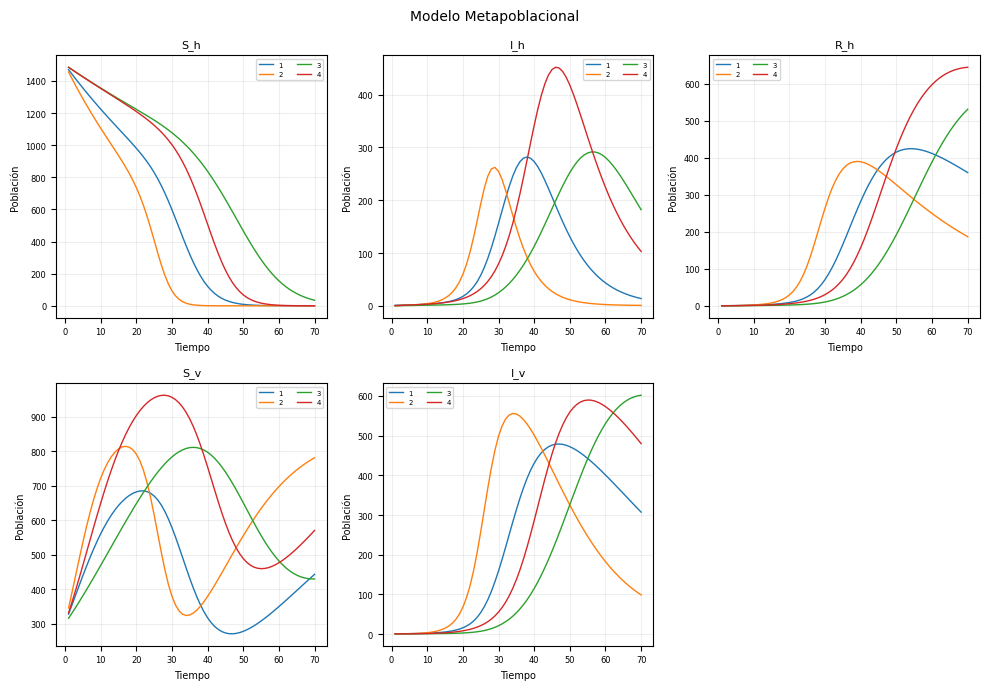

In [13]:
P = MobilityNetwork()
P.random(n,n,min_residential)
control = IndexBasedControl(update_interval=None)
vectorModelEndemic = VectorBorne_Endemic(n,params=param, network=P, control=control)

sim  = simulation(vectorModelEndemic)
sim.set_initial_conditions_all_patches(y)
y[1]=y[1]+1. # Se agrega 1 infectado a las condiciones iniciales
sim.set_initial_conditions_patch(0,y) #Se establece esta condicion inicial en la zona 1
sim.set_simulation_time(70) #How many "days" to simulate

ensemble = simulationsEnsemble()
ensemble.add_simulation(sim)

for i in range(number_of_simulations):
    P.random(n,n,min_residential)
    ensemble.add_simulation(sim)

ensemble.run_all_simulations()

t_evalu = np.linspace(1,70,70)
lab = ['S_h', 'I_h', 'R_h', 'S_v','I_v']
sol, ev = sim.run_modified(t_evaluation = t_evalu)
print(np.shape(ev))
RegValGrid(4,5, ev, t_evalu, lab)

In [15]:
# Usando pydmd (Se normalizan los datos antes)
Dat = stats.zscore(ev, axis=1, ddof=1)
dmd_1 = DMD(
    svd_rank=10,
    tlsq_rank=5,  
    exact=True,
    sorted_eigs='abs'
)
dmd_1.fit(Dat)

(20, 10)


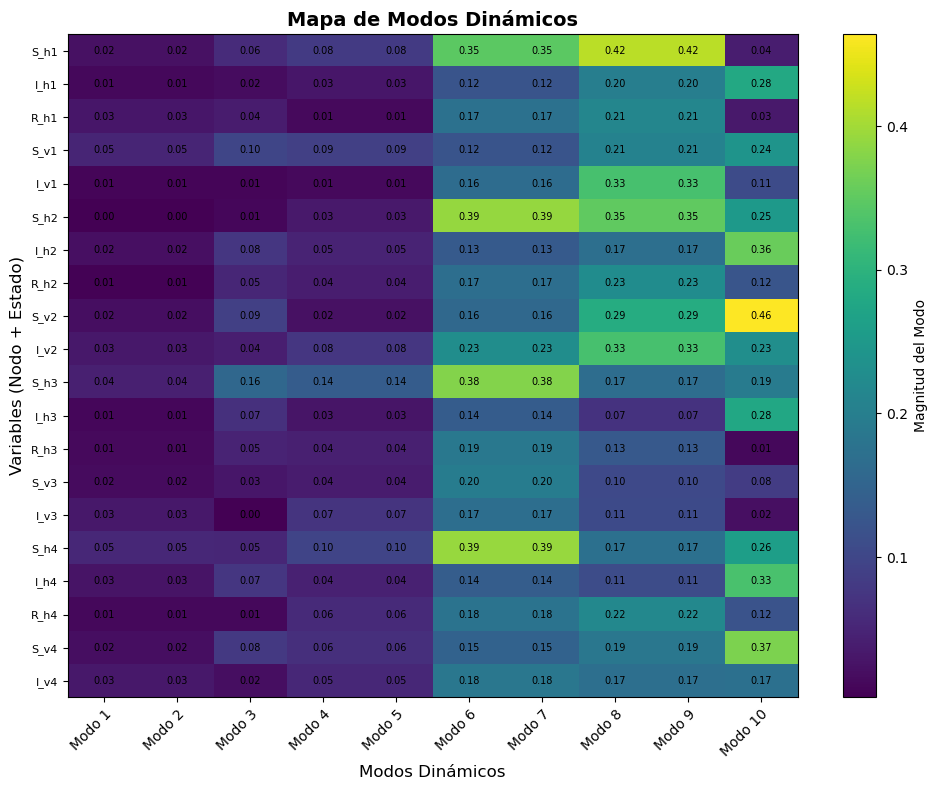

In [17]:
modes = dmd_1.modes
print(np.shape(modes))
etiquetas = gen_labels(4)
graficar_modos(modes, etiquetas, titulo="Mapa de Modos Dinámicos")

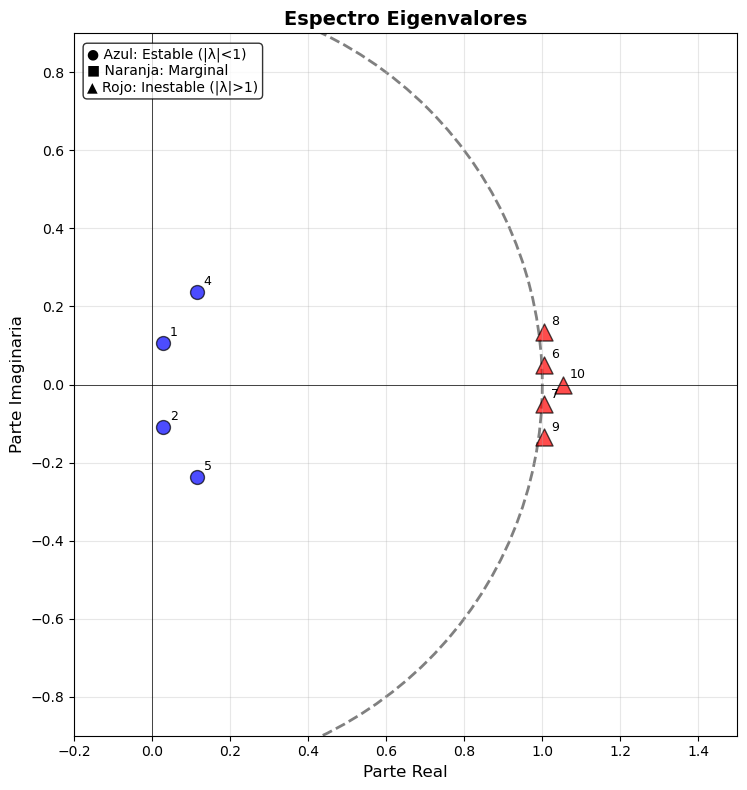

In [19]:
eigenvalues = dmd_1.eigs
espectro(eigenvalues)

In [21]:
ranking, modes_dom = dominant_modes(dmd_1, T=15, top=5)
print(ranking)

   mode          eigenvalue  |lambda|           amplitude       |b|     score
0     7  1.003759-0.051075j  1.005058 -2.281717-0.221111j  2.292406  2.472613
1     6  1.003759+0.051075j  1.005058 -2.281717+0.221111j  2.292406  2.472613
2    10  1.052458+0.000000j  1.052458  0.696249-0.000000j  0.696249  1.499116
3     9  1.004849-0.135634j  1.013962  0.205948+0.541520j  0.579361  0.713300
4     8  1.004849+0.135634j  1.013962  0.205948-0.541520j  0.579361  0.713300


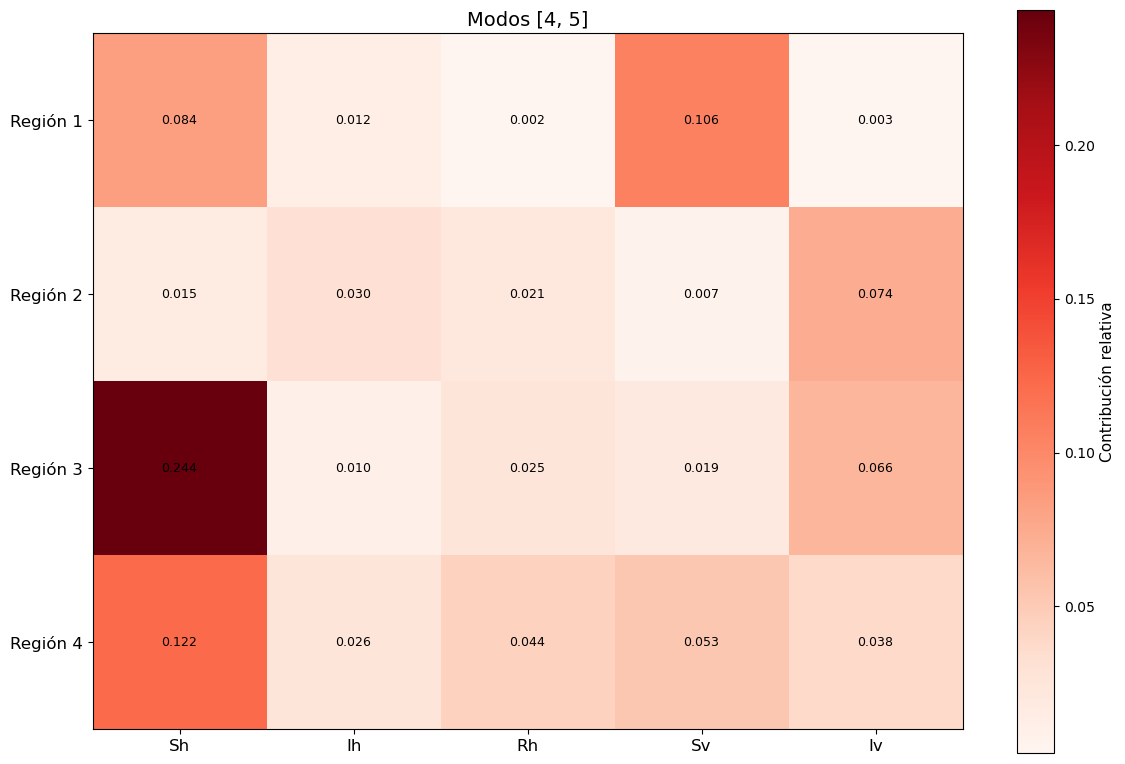

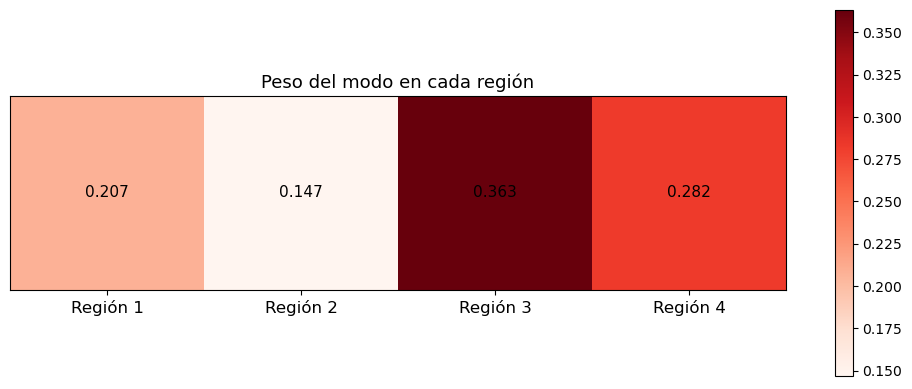

array([[0.08424894, 0.01209385, 0.00246913, 0.10569274, 0.0027521 ],
       [0.01502178, 0.03039934, 0.02086767, 0.00699591, 0.07364693],
       [0.24396266, 0.00990909, 0.02470667, 0.01907768, 0.06570361],
       [0.1220135 , 0.02595253, 0.04352924, 0.05304824, 0.0379084 ]])

In [23]:
dominant_heatmap(
    dmd_1,
    [4,5],
    n_regions=4,
    vars_per_region=5,
    var_names=("Sh", "Ih", "Rh", "Sv", "Iv"),
    combine_amplitudes=True,
    normalize=True,
    cmap="Reds"
)

# 8 regiones

In [26]:
# Asignación de parámetros 
number_of_simulations = 50
n = 8 #Regiones 
min_residential = 0.9 # diagonal de la matriz de mobilidad mayor a este numero

params_alto_riesgo = np.array([
    # zeta     mu_h     mu_v     beta_h   beta_v   gamma    alpha    carry
    [0.00008, 0.00004, 0.045,   0.85,    0.90,    0.10,    0.28,    1200],  
    [0.00007, 0.00005, 0.050,   0.78,    0.85,    0.11,    0.25,    1100],  
    [0.00009, 0.00004, 0.040,   0.92,    0.95,    0.09,    0.30,    1400],  
    [0.00006, 0.00006, 0.055,   0.70,    0.80,    0.12,    0.22,    900],   
    [0.00008, 0.00005, 0.048,   0.88,    0.92,    0.10,    0.27,    1150],  
    [0.00010, 0.00004, 0.038,   0.95,    0.98,    0.08,    0.32,    1500],  
    [0.00005, 0.00007, 0.060,   0.65,    0.75,    0.13,    0.20,    800],   
    [0.00007, 0.00005, 0.052,   0.82,    0.88,    0.11,    0.26,    1050]    
])
#initial conditions para una zona
y = np.zeros(5)
S_h = y[0] = 1500.0
I_h = y[1] = 1.0
R_h = y[2] = 0.0
S_v = y[3] = 200.0
I_v = y[4] = 1.0

(8, 5, 60)


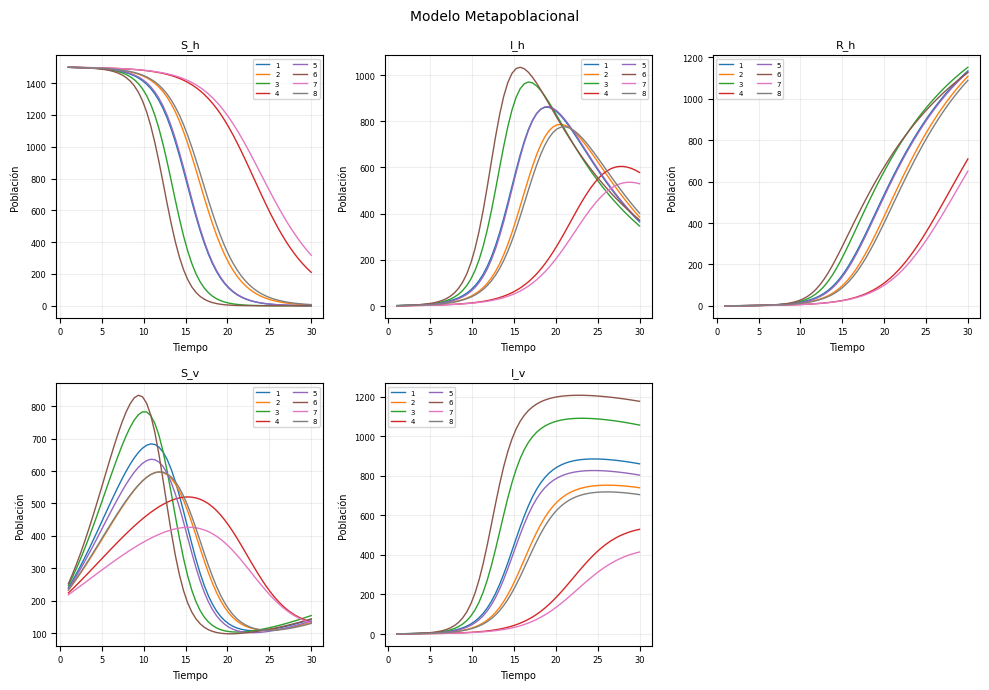

In [28]:
P = MobilityNetwork()
P.random(n,n,min_residential=min_residential)
control = IndexBasedControl(update_interval=None)
vectorModelEndemic = VectorBorne_Endemic(n,params=params_alto_riesgo, network=P, control=control)

sim  = simulation(vectorModelEndemic)
sim.set_initial_conditions_all_patches(y)
y[1]=y[1]+1. # Se agrega 1 infectado a las condiciones iniciales
sim.set_initial_conditions_patch(0,y) #Se establece esta condicion inicial en la zona 1
sim.set_simulation_time(30) #How many "days" to simulate

ensemble = simulationsEnsemble()
ensemble.add_simulation(sim)

for i in range(number_of_simulations):
    P.random(n,n,min_residential=min_residential)
    ensemble.add_simulation(sim)

ensemble.run_all_simulations()

t_evalu = np.linspace(1,30,60)
lab = ['S_h', 'I_h', 'R_h', 'S_v','I_v']
sol, ev = sim.run_modified(t_evaluation = t_evalu)
print(np.shape(ev))
RegValGrid(n, 5, ev, t_evalu, lab)
#Graficar las regiones y la evolución de cada vatiable en el tiempo 

In [30]:
# Usando pydmd
Dat = stats.zscore(ev, axis=1, ddof=1)
dmd = DMD(
    svd_rank=20,
    tlsq_rank=10,  
    exact=True,
    sorted_eigs='abs'
)
dmd.fit(Dat)

(40, 20)


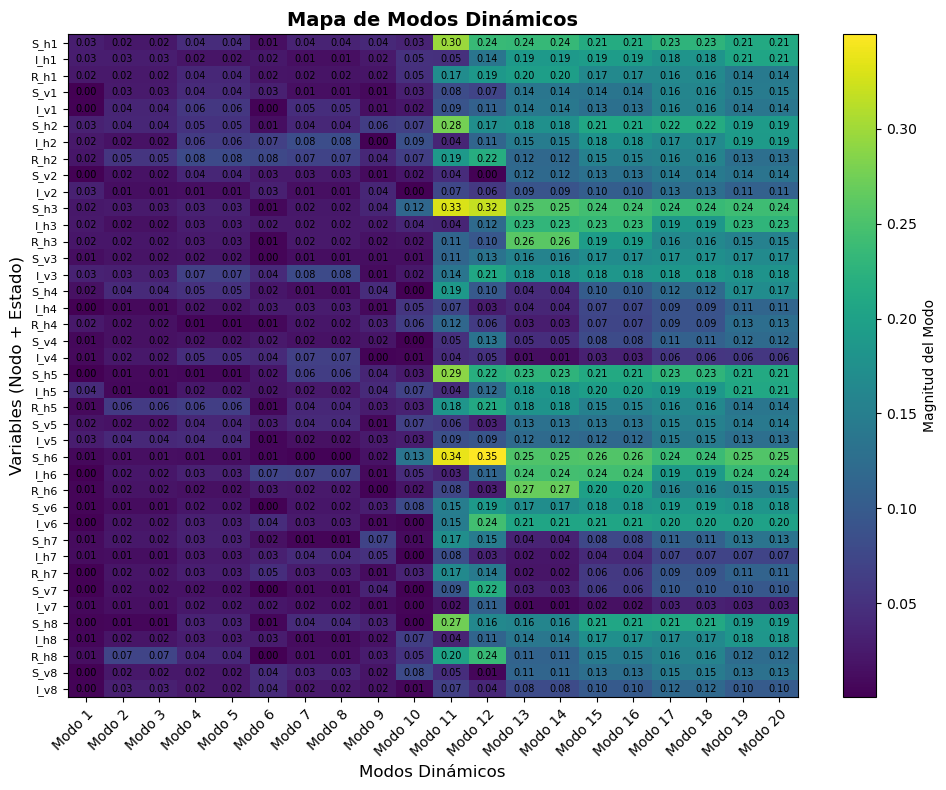

In [32]:
modes = dmd.modes
print(np.shape(modes))
etiquetas = gen_labels(8)
graficar_modos(modes, etiquetas, titulo="Mapa de Modos Dinámicos")

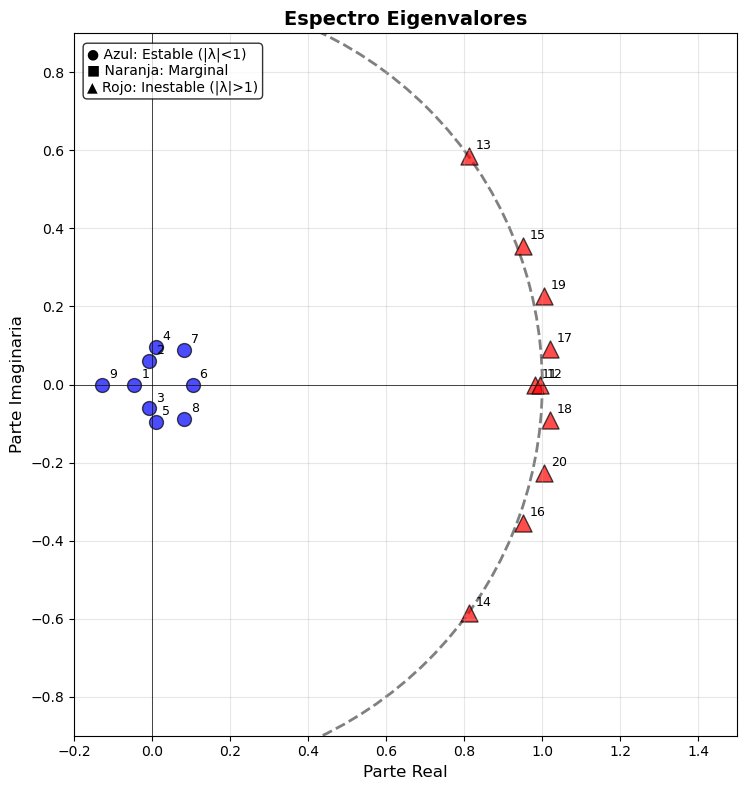

In [34]:
eigenvalues = dmd.eigs
espectro(eigenvalues)

In [72]:
ranking, modes_dom = dominant_modes(dmd, T=30, top=5)

print(ranking)

   mode          eigenvalue  |lambda|           amplitude       |b|     score
0    10  0.994092-0.105801j  0.999706  0.674222-4.141392j  4.195915  4.159076
1     9  0.994092+0.105801j  0.999706  0.674222+4.141392j  4.195915  4.159076
2     8  0.964140-0.226675j  0.990428  0.480267-1.705990j  1.772303  1.328066
3     7  0.964140+0.226675j  0.990428  0.480267+1.705990j  1.772303  1.328066
4     6  0.897007-0.328586j  0.955296  2.390250+1.769609j  2.974023  0.754202


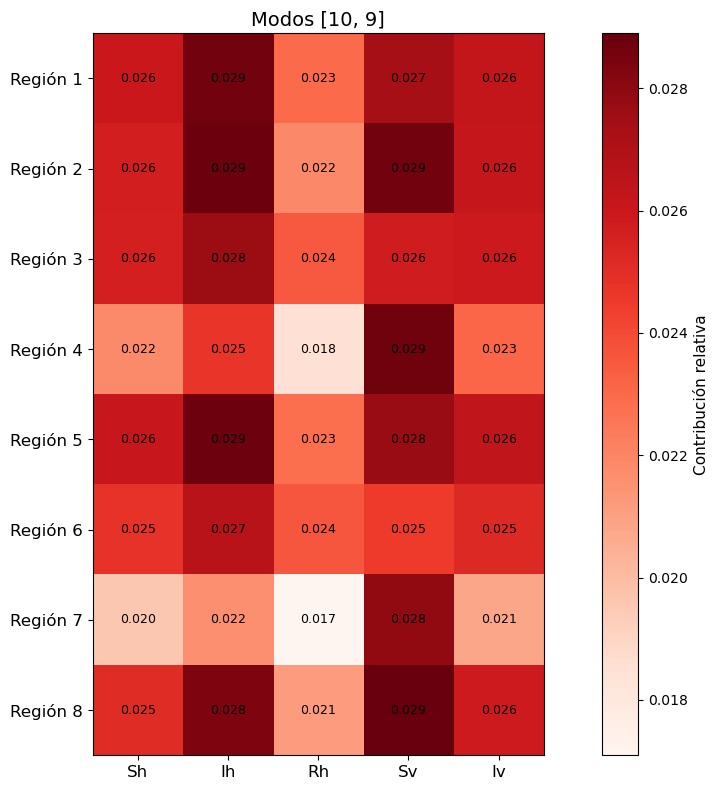

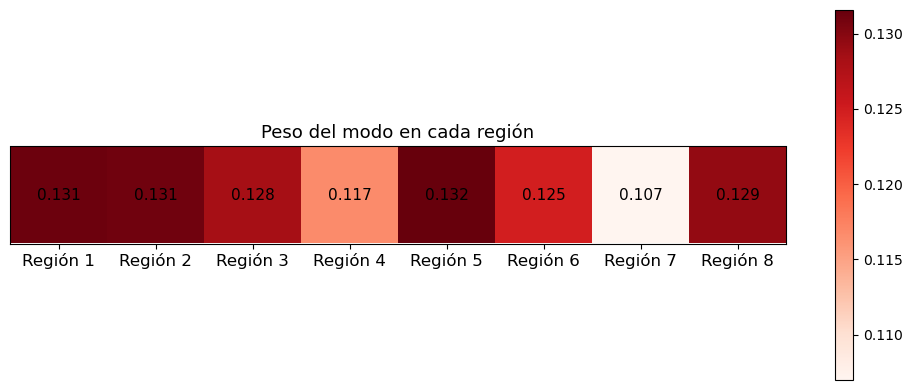

array([[0.0259814 , 0.02861365, 0.02298844, 0.02736786, 0.02625541],
       [0.0256401 , 0.02874326, 0.02186683, 0.02859677, 0.02614526],
       [0.0255949 , 0.02762665, 0.0235244 , 0.02574602, 0.02586825],
       [0.02184348, 0.0246876 , 0.01847185, 0.02864619, 0.02309359],
       [0.02604929, 0.02870338, 0.02277559, 0.02768523, 0.02634809],
       [0.02480713, 0.02671619, 0.02360126, 0.02450199, 0.02519285],
       [0.01955297, 0.02164474, 0.01709481, 0.02787898, 0.02082707],
       [0.02509848, 0.02833803, 0.0211572 , 0.02889742, 0.02582737]])

In [74]:
dominant_heatmap(
    dmd,
    [10,9],
    n_regions=8,
    vars_per_region=5,
    var_names=("Sh", "Ih", "Rh", "Sv", "Iv"),
    combine_amplitudes=True,
    normalize=True,
    cmap="Reds"
)